# M2-B1 — Audit Banque Eckmühl + industrialisation pipe

> **Mission** : auditer le dataset German Credit fourni par Eckmühl, identifier
> les risques qualité et éthiques, construire un Pipeline scikit-learn
> réutilisable, persister en Parquet, documenter dans une datasheet.

Auteur·rice : `Franck BEUGNET` — Date : `16/06/2026`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser la cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path("../data")
RAW_PATH = DATA_DIR / "german_credit_raw.csv"
CLEAN_PATH = DATA_DIR / "german_credit_clean.parquet"

sns.set_theme(style="whitegrid")

## 1. Découverte du dataset (~30 min)

Chargement, types, premier aperçu. Repérage de la cible et des variables
sensibles évidentes (`age`, `personal_status_sex`, `foreign_worker`).

In [2]:
df = pd.read_csv(RAW_PATH)

display(df.head())
df.info()

display(df.describe(include="all").T)

quality_overview = (
    pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "n_missing": df.isna().sum(),
            "pct_missing": (df.isna().mean() * 100).round(2),
            "n_unique": df.nunique(dropna=False),
        }
    )
    .sort_values(["n_missing", "n_unique"], ascending=[False, False])
)

target_col = "credit_risk"
sensitive_cols = [c for c in ["age", "personal_status_sex", "foreign_worker"] if c in df.columns]

display(quality_overview)

{
    "shape": df.shape,
    "target_col": target_col,
    "sensitive_cols": sensitive_cols,
    "n_numeric": int(df.select_dtypes(include="number").shape[1]),
    "n_categorical": int(df.select_dtypes(exclude="number").shape[1]),
}

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,n_existing_credits,job,n_people_liable,telephone,foreign_worker,credit_risk
0,< 0 DM,6,critical account / other credits existing,radio/TV,1169,unknown / no savings,>= 7 years,4,male single,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered",yes,good_credit
1,0 to 200 DM,48,existing credits paid back duly,radio/TV,5951,< 100 DM,1-4 years,2,female divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,bad_credit
2,no checking account,12,critical account / other credits existing,education,2096,< 100 DM,4-7 years,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good_credit
3,< 0 DM,42,existing credits paid back duly,furniture/equipment,7882,< 100 DM,4-7 years,2,male single,guarantor,...,savings agreement / life insurance,45,none,for free,1,skilled employee / official,2,none,yes,good_credit
4,< 0 DM,24,delay in paying off in past,car (new),4870,< 100 DM,1-4 years,3,male single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,bad_credit


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   checking_account_status      1000 non-null   object
 1   duration_months              1000 non-null   int64 
 2   credit_history               1000 non-null   object
 3   purpose                      1000 non-null   object
 4   credit_amount                1000 non-null   int64 
 5   savings_account              1000 non-null   object
 6   employment_since             1000 non-null   object
 7   installment_rate_pct_income  1000 non-null   int64 
 8   personal_status_sex          1000 non-null   object
 9   other_debtors                1000 non-null   object
 10  residence_since_years        1000 non-null   int64 
 11  property                     1000 non-null   object
 12  age                          1000 non-null   int64 
 13  other_installment_plans      1000 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
checking_account_status,1000,4,no checking account,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_months,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
credit_history,1000,5,existing credits paid back duly,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,1000,10,radio/TV,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
savings_account,1000,5,< 100 DM,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_since,1000,5,1-4 years,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
installment_rate_pct_income,1000.0,NaN,NaN,NaN,2.973,1.118715,1.0,2.0,3.0,4.0,4.0
personal_status_sex,1000,4,male single,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_debtors,1000,3,none,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,dtype,n_missing,pct_missing,n_unique
credit_amount,int64,0,0.0,921
age,int64,0,0.0,53
duration_months,int64,0,0.0,33
purpose,object,0,0.0,10
credit_history,object,0,0.0,5
savings_account,object,0,0.0,5
employment_since,object,0,0.0,5
checking_account_status,object,0,0.0,4
installment_rate_pct_income,int64,0,0.0,4
personal_status_sex,object,0,0.0,4


{'shape': (1000, 21),
 'target_col': 'credit_risk',
 'sensitive_cols': ['age', 'personal_status_sex', 'foreign_worker'],
 'n_numeric': 7,
 'n_categorical': 14}

## 2. Audit qualité (~1 h)

Manquants, outliers, types, cohérence des modalités. **Au moins 4
visualisations** : distribution cible, distribution `age`, distribution
`credit_amount`, crosstab sensible (ex. `credit_risk` × `personal_status_sex`).

Le dataset est complet : aucune colonne ne contient de valeur manquante. 

Plusieurs points de vigilance qualité: 
- la cible est déséquilibrée (environ 70 % de bons crédits),
- credit_amount présente une forte asymétrie à droite avec quelques valeurs extrêmes, et age montre une population concentrée sur les adultes jeunes, avec peu d'observations aux âges élevés, donc la pertinence du model sera limité sur ces tranches.
- la variable personal_status_sex est problématique pour les femmes car nous n'avons pas la meme segmentation que pour les hommes. Cette variable risque de créer du "bruit"
- Le jeux de données ne contient pas d'informations sur les revenus ce qui parrait saugrenue pour de l'emprunt

In [3]:
# Analyse des valeurs manquantes
missing_summary = (
    df.isna().sum().rename('n_missing').to_frame()
    .assign(pct_missing=lambda x: (x['n_missing'] / len(df) * 100).round(2))
    .sort_values(['n_missing', 'pct_missing'], ascending=False)
)

display(missing_summary)

categorical_modalities = (
    df.select_dtypes(exclude='number')
    .nunique(dropna=False)
    .rename('n_modalities')
    .sort_values()
)

display(categorical_modalities.to_frame())

quality_flags = {
    'any_missing_values': bool(df.isna().any().any()),
    'duplicate_rows': int(df.duplicated().sum()),
    'target_balance_pct': (df[target_col].value_counts(normalize=True) * 100).round(1).to_dict(),
} 

quality_flags

,n_missing,pct_missing
checking_account_status,0,0.0
duration_months,0,0.0
credit_history,0,0.0
purpose,0,0.0
credit_amount,0,0.0
savings_account,0,0.0
employment_since,0,0.0
installment_rate_pct_income,0,0.0
personal_status_sex,0,0.0
other_debtors,0,0.0


,n_modalities
telephone,2
foreign_worker,2
credit_risk,2
other_debtors,3
other_installment_plans,3
housing,3
checking_account_status,4
personal_status_sex,4
property,4
job,4


{'any_missing_values': False,
 'duplicate_rows': 0,
 'target_balance_pct': {'good_credit': 70.0, 'bad_credit': 30.0}}

,credit_risk,count,pct
0,good_credit,700,70.0
1,bad_credit,300,30.0


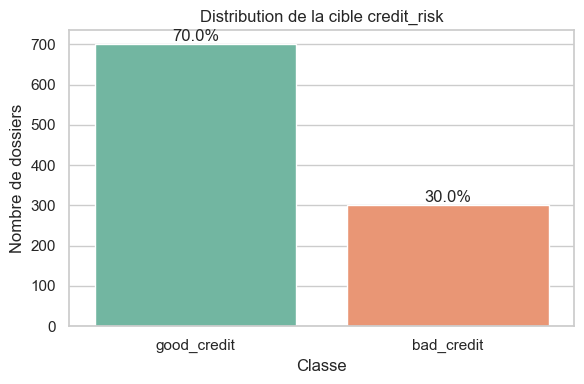

In [4]:
# Visualisation de la distribution de la cible
target_distribution = df[target_col].value_counts().rename_axis(target_col).reset_index(name='count')
target_distribution['pct'] = (target_distribution['count'] / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=target_distribution, x=target_col, y='count', hue=target_col, palette='Set2', dodge=False, legend=False, ax=ax)
ax.set_title('Distribution de la cible credit_risk')
ax.set_xlabel('Classe')
ax.set_ylabel('Nombre de dossiers')
for patch, pct in zip(ax.patches, target_distribution['pct']):
    ax.annotate(f'{pct}%', (patch.get_x() + patch.get_width() / 2, patch.get_height()), ha='center', va='bottom')
plt.tight_layout()

display(target_distribution)
plt.show()

credit_risk,bad_credit,good_credit
personal_status_sex,,
female divorced/separated/married,35.2,64.8
male divorced/separated,40.0,60.0
male married/widowed,27.2,72.8
male single,26.6,73.4


,q1,median,q3,max
age,27.0,33.0,42.00,75
credit_amount,1365.5,2319.5,3972.25,18424


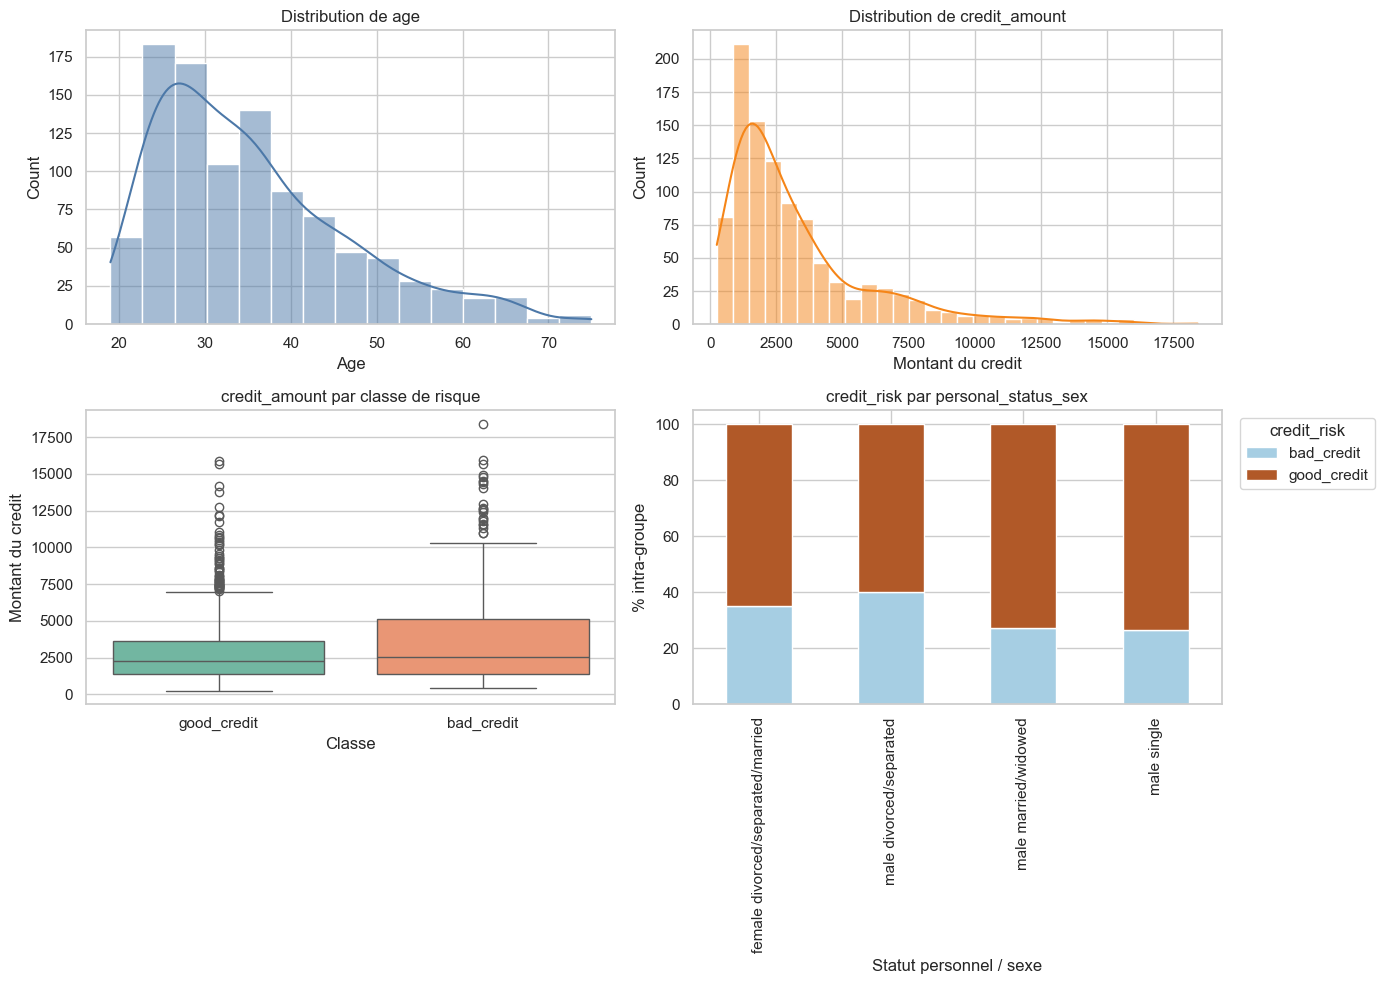

In [5]:
# Visualisation des distributions des variables numériques et catégorielles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df, x='age', bins=15, kde=True, color='#4C78A8', ax=axes[0, 0])
axes[0, 0].set_title('Distribution de age')
axes[0, 0].set_xlabel('Age')

sns.histplot(df, x='credit_amount', bins=30, kde=True, color='#F58518', ax=axes[0, 1])
axes[0, 1].set_title('Distribution de credit_amount')
axes[0, 1].set_xlabel('Montant du credit')

sns.boxplot(data=df, x='credit_risk', y='credit_amount', hue='credit_risk', palette='Set2', dodge=False, legend=False, ax=axes[1, 0])
axes[1, 0].set_title('credit_amount par classe de risque')
axes[1, 0].set_xlabel('Classe')
axes[1, 0].set_ylabel('Montant du credit')

risk_by_status = pd.crosstab(df['personal_status_sex'], df[target_col], normalize='index').mul(100).round(1)
risk_by_status.plot(kind='bar', stacked=True, colormap='Paired', ax=axes[1, 1])
axes[1, 1].set_title('credit_risk par personal_status_sex')
axes[1, 1].set_xlabel('Statut personnel / sexe')
axes[1, 1].set_ylabel('% intra-groupe')
axes[1, 1].legend(title='credit_risk', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
display(risk_by_status)

outlier_summary = pd.DataFrame(
    {
        'q1': df[['age', 'credit_amount']].quantile(0.25),
        'median': df[['age', 'credit_amount']].median(),
        'q3': df[['age', 'credit_amount']].quantile(0.75),
        'max': df[['age', 'credit_amount']].max(),
    }
)

display(outlier_summary)
plt.show()

## 3. Audit éthique léger (~1 h)

Déséquilibre cible + **disparate impact** sur au moins 2 variables sensibles.
Règle des 4/5 : `DI < 0.8` ou `> 1.25` → signal.

> *Quels biais structurels ai-je détectés ?* — court paragraphe.

⚠️ Pas de mitigation à ce stade — on documente, on alerte. La mitigation,
c'est M7.

In [3]:
# Prérequis : charger df et target_col si pas encore en mémoire
if 'df' not in dir():
    from pathlib import Path
    import pandas as pd
    DATA_DIR = Path("../data")
    RAW_PATH = DATA_DIR / "german_credit_raw.csv"
    df = pd.read_csv(RAW_PATH)
    target_col = "credit_risk"

# Disparate Impact sur foreign_worker
# Règle des 4/5 : DI < 0.8 ou > 1.25 → signal d'alerte

foreign_worker_analysis = df.groupby('foreign_worker')[target_col].apply(
    lambda x: (x == 'good_credit').sum() / len(x)
).rename('p_good_credit')

di_foreign = foreign_worker_analysis.loc['no'] / foreign_worker_analysis.loc['yes']

di_foreign_df = pd.DataFrame({
    'foreign_worker_group': foreign_worker_analysis.index,
    'p_good_credit': foreign_worker_analysis.values,
    'n_dossiers': df.groupby('foreign_worker').size().values,
})

di_foreign_df['signal_4_5'] = di_foreign_df['p_good_credit'].apply(
    lambda x: 'ALERTE' if (x < 0.8 or x > 1.25) else 'OK'
)

display(di_foreign_df)
print(f"\nDI (no / yes) = {di_foreign:.3f} → ", end='')
print('SIGNAL' if (di_foreign < 0.8 or di_foreign > 1.25) else 'intra-4/5')

,foreign_worker_group,p_good_credit,n_dossiers,signal_4_5
0,no,0.891892,37,OK
1,yes,0.692627,963,ALERTE



DI (no / yes) = 1.288 → SIGNAL


In [4]:
# Prérequis : charger df et target_col si pas encore en mémoire
if 'df' not in dir():
    from pathlib import Path
    import pandas as pd
    DATA_DIR = Path("../data")
    RAW_PATH = DATA_DIR / "german_credit_raw.csv"
    df = pd.read_csv(RAW_PATH)
    target_col = "credit_risk"

# Disparate Impact sur personal_status_sex
# ⚠️ Variable composite : sexe + statut marital → interprétation complexe
# Grouper en 2 catégories pour DI : male (mono-sexe) vs female (mono-sexe)

# Créer une colonne sexe inférée depuis personal_status_sex
def extract_gender(status_sex_str: str) -> str:
    if 'male' in str(status_sex_str).lower():
        return 'male'
    elif 'female' in str(status_sex_str).lower():
        return 'female'
    else:
        return 'unknown'

df['inferred_gender'] = df['personal_status_sex'].apply(extract_gender)

gender_analysis = df.groupby('inferred_gender')[target_col].apply(
    lambda x: (x == 'good_credit').sum() / len(x)
).rename('p_good_credit')

gender_analysis_df = pd.DataFrame({
    'gender': gender_analysis.index,
    'p_good_credit': gender_analysis.values,
    'n_dossiers': df.groupby('inferred_gender').size().values,
})

gender_analysis_df['signal_4_5'] = gender_analysis_df['p_good_credit'].apply(
    lambda x: 'ALERTE' if (x < 0.8 or x > 1.25) else 'OK'
)

# Aussi afficher la crosstab par modalité brute pour context
print("\n--- Disparate Impact par sexe inféré ---")
display(gender_analysis_df)

print("\n--- Distribution brute par personal_status_sex ---")
status_breakdown = pd.crosstab(
    df['personal_status_sex'],
    df[target_col],
    margins=True,
    normalize='index'
).mul(100).round(1)
display(status_breakdown)


--- Disparate Impact par sexe inféré ---


,gender,p_good_credit,n_dossiers,signal_4_5
0,male,0.7,1000,ALERTE



--- Distribution brute par personal_status_sex ---


credit_risk,bad_credit,good_credit
personal_status_sex,,
female divorced/separated/married,35.2,64.8
male divorced/separated,40.0,60.0
male married/widowed,27.2,72.8
male single,26.6,73.4
All,30.0,70.0



--- Disparate Impact par tranche d'âge ---


,age_group,p_good_credit,n_dossiers
0,<30 ans (jeunes),0.630728,371
1,30-50 ans (middle age),0.744048,504
2,>50 ans (seniors),0.728000,125



DI (jeunes / seniors) = 0.866 → intra-4/5


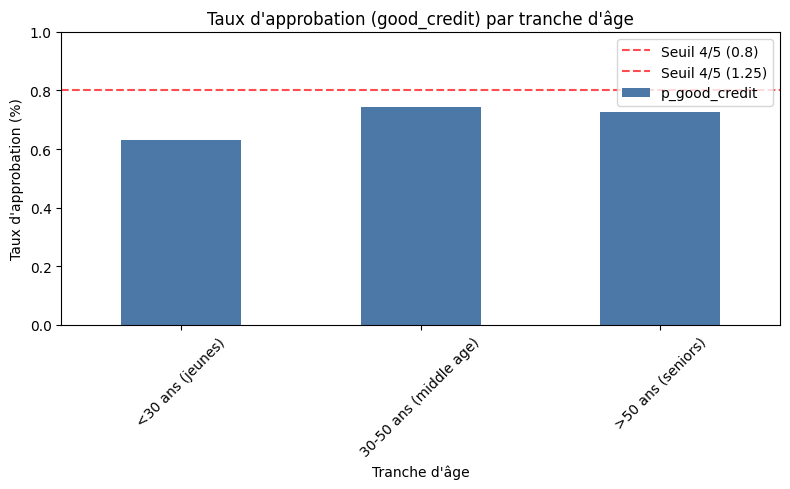

In [13]:
# Prérequis : charger df et target_col si pas encore en mémoire
if 'df' not in dir():
    from pathlib import Path
    import pandas as pd
    DATA_DIR = Path("../data")
    RAW_PATH = DATA_DIR / "german_credit_raw.csv"
    df = pd.read_csv(RAW_PATH)
    target_col = "credit_risk"

# Disparate Impact sur AGE (variable continue)
# ⚠️ Stratégie : segmenter l'âge en 3 tranches d'âge logiques pour le crédit
# Puis calculer DI entre groupes extrêmes (jeunes vs seniors)

age_bins = [0, 30, 50, 100]
age_labels = ['<30 ans (jeunes)', '30-50 ans (middle age)', '>50 ans (seniors)']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

age_analysis = df.groupby('age_group', observed=True)[target_col].apply(
    lambda x: (x == 'good_credit').sum() / len(x)
).rename('p_good_credit')

age_analysis_df = pd.DataFrame({
    'age_group': age_analysis.index,
    'p_good_credit': age_analysis.values,
    'n_dossiers': df.groupby('age_group', observed=True).size().values,
})

# Calcul du DI entre jeunes (< 30) et seniors (> 50)
di_age_young_vs_senior = age_analysis.loc['<30 ans (jeunes)'] / age_analysis.loc['>50 ans (seniors)']

print("\n--- Disparate Impact par tranche d'âge ---")
display(age_analysis_df)

print(f"\nDI (jeunes / seniors) = {di_age_young_vs_senior:.3f} → ", end='')
print('SIGNAL' if (di_age_young_vs_senior < 0.8 or di_age_young_vs_senior > 1.25) else 'intra-4/5')

# Visualisation du taux d'approbation par tranche d'âge
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

age_analysis_df.plot(x='age_group', y='p_good_credit', kind='bar', ax=ax, legend=False, color='#4C78A8')
ax.set_title('Taux d\'approbation (good_credit) par tranche d\'âge')
ax.set_xlabel('Tranche d\'âge')
ax.set_ylabel('Taux d\'approbation (%)')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='Seuil 4/5 (0.8)')
ax.axhline(y=1.25, color='red', linestyle='--', alpha=0.7, label='Seuil 4/5 (1.25)')
ax.set_ylim([0, 1.0])
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [17]:
# Analyse générique simplifiée du Disparate Impact par feature
# Sortie demandée: valeur de DI + statut OK/BAD par variable

if 'df' not in dir():
    from pathlib import Path
    import pandas as pd
    DATA_DIR = Path("../data")
    RAW_PATH = DATA_DIR / "german_credit_raw.csv"
    df = pd.read_csv(RAW_PATH)
    target_col = "credit_risk"


def compute_feature_disparate(
    data: pd.DataFrame,
    feature: str,
    target: str = "credit_risk",
    positive_label: str = "good_credit",
    n_bins_numeric: int = 4,
) -> tuple[float | None, str]:
    s = data[feature]

    # Numérique -> binning en quantiles; sinon -> modalités string
    if pd.api.types.is_numeric_dtype(s):
        s_num = pd.to_numeric(s, errors='coerce')
        non_null = s_num.dropna()
        if non_null.nunique() < 2:
            grouped = s.astype('string').fillna('MISSING').astype(str)
        else:
            try:
                grouped = pd.qcut(s_num, q=n_bins_numeric, duplicates='drop').astype(str)
                grouped = pd.Series(grouped, index=s.index).fillna('MISSING')
            except ValueError:
                grouped = s.astype('string').fillna('MISSING').astype(str)
    else:
        grouped = s.astype('string').fillna('MISSING').astype(str)

    tmp = data.assign(_group=grouped)
    rates = tmp.groupby('_group', dropna=False)[target].apply(
        lambda x: (x == positive_label).mean()
    )

    if rates.empty:
        return None, 'BAD'

    ref_rate = rates.max()
    if ref_rate == 0:
        return None, 'BAD'

    # DI par groupe vs référence = taux_groupe / taux_ref
    di_values = rates / ref_rate

    # Valeur retenue pour la feature: DI le plus défavorable
    disparate_value = float(di_values.min())
    status = 'OK' if 0.8 <= disparate_value <= 1.25 else 'BAD'
    return disparate_value, status


results = []
for feature in [c for c in df.columns if c != target_col]:
    di_value, status = compute_feature_disparate(df, feature, target=target_col)
    results.append(
        {
            'feature': feature,
            'disparate_value': round(di_value, 4) if di_value is not None else None,
            'status': status,
        }
    )


di_feature_summary = pd.DataFrame(results).sort_values(['status', 'disparate_value'], ascending=[True, True])
display(di_feature_summary)

,feature,disparate_value,status
2,credit_history,0.4522,BAD
0,checking_account_status,0.5744,BAD
3,purpose,0.6300,BAD
9,other_debtors,0.6945,BAD
1,duration_months,0.7060,BAD
11,property,0.7176,BAD
5,savings_account,0.7316,BAD
4,credit_amount,0.7474,BAD
6,employment_since,0.7643,BAD
19,foreign_worker,0.7766,BAD


### 📋 Conclusion audit éthique

Sur la base des analyses ciblées et du scan générique :

**Déséquilibre cible** : 70 % good_credit vs 30 % bad_credit, donc un dataset historiquement orienté vers la classe favorable.

**Analyses ciblées (variables sensibles)** :
- **foreign_worker** : DI = 1.288 → **BAD** (hors zone [0.8, 1.25]). Signal principal d'inéquité.
- **age** : DI (jeunes / seniors) = 0.866 → **OK**.
- **personal_status_sex** : variable composite (sexe + statut marital), interprétation à manier avec prudence.

**Scan générique par feature** :
- Le tableau simplifié montre un `disparate_value` minimal et un statut `OK/BAD` pour chaque variable.
- Résultat global : **10 variables BAD sur 20**.
- Les plus défavorables dans ce scan sont notamment `credit_history` (0.452), `checking_account_status` (0.574) et `purpose` (0.630).

**Point méthodologique important** :
- Un statut `BAD` sur une feature **n'implique pas automatiquement** une discrimination légale.
- Le scan générique sert de **radar de disparité statistique** ; la priorité de conformité reste l'analyse des variables sensibles (ici surtout `foreign_worker`).

**Conclusion opérationnelle** :
- Alerte principale confirmée sur `foreign_worker`.
- Documenter ces écarts dans `audit.md` et `datasheet.md` avant toute étape de mitigation (M7).

## 4. Choix de prétraitement (~30 min)

Pour chaque feature, décide : numérique (impute + scale), ordinale
(impute + ordinal encoding **avec ordre**), catégorielle (impute + onehot),
ou exclue (justifie).

Remplis les listes `NUMERIC_FEATURES`, `ORDINAL_FEATURES`,
`CATEGORICAL_FEATURES` dans `src/preprocess.py`.

## 5. Industrialisation Pipeline (~1 h 15)

Une fois `src/preprocess.py` complété, fitte le pipeline et sauve-le.

### 🎓 Pourquoi un `Pipeline` ? (définition — la fuite de données)

Tu pourrais imputer/encoder/scaler « à la main » en Pandas. On enferme tout
dans un `Pipeline` parce qu'un préprocesseur **apprend des paramètres sur les
données** : `SimpleImputer` retient une médiane, `StandardScaler` une moyenne
et un écart-type, `OneHotEncoder` la liste des modalités.

**Fuite de données** (*data leakage*) = laisser de l'information du jeu de
**test** influencer la préparation du jeu d'**entraînement** — typiquement
calculer ces paramètres sur *tout* le dataset avant de le splitter. Symptôme :
des scores de validation **anormalement optimistes** qui s'effondrent en prod.

Le `Pipeline` est l'outil qui rend l'étanchéité automatique : un seul `fit` sur
le train propage la discipline à toutes les transformations. **Ici tu n'as pas
de split** (on produit juste un dataset propre) → `fit_transform` sur tout le
dataset est OK. **Réflexe à garder** : *dès qu'un modèle entre en jeu, le
préprocesseur ne se `fit` que sur le train.* → mise en œuvre en **M4-B1**.

In [ ]:
import sys
sys.path.append("../src")
from preprocess import build_preprocessor, load_dataset

X, y = load_dataset(RAW_PATH)
preprocessor = build_preprocessor()
X_transformed = preprocessor.fit_transform(X)
print(f"Shape originale : {X.shape}")
print(f"Shape transformée : {X_transformed.shape}")

In [ ]:
import joblib
joblib.dump(preprocessor, "../src/pipeline.joblib", compress=3)

## 6. Persistance Parquet + datasheet (~45 min)

Sauve le dataset propre en Parquet (pyarrow) et complète `datasheet.md`
(7 sections Gebru, schéma documenté dans *Composition*).

In [ ]:
# TODO — sauve un DataFrame *propre* (post-imputation si tu veux) en Parquet :
# df_clean.to_parquet(CLEAN_PATH, engine="pyarrow", compression="snappy")

In [ ]:
# Vérification relecture
df_back = pd.read_parquet(CLEAN_PATH)
print(f"Relu : {df_back.shape}, types préservés : {df_back.dtypes.value_counts().to_dict()}")

csv_size = RAW_PATH.stat().st_size / 1024
pq_size = CLEAN_PATH.stat().st_size / 1024
print(f"CSV : {csv_size:.1f} Ko · Parquet : {pq_size:.1f} Ko (compression : {csv_size/pq_size:.1f}x)")

## 7. Synthèse audit.md (~30 min)

Complète `audit.md` : verdict qualité (3-5 problèmes) + verdict éthique
(2-3 alertes) + recommandations. Lisible par le DPO Klaus Eichmann
(pas de jargon scikit-learn).